In [1]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters
Trot = 200          # Rotational temperature in K
Tvib = 9000         # Vibrational temperature in K
#N = 3e10            # Number of molecules per cm^2


In [3]:
# Get the current working directory
dir = os.getcwd()

# File paths
energies_path = os.path.join(dir, 'energies.dat')
probas_path = os.path.join(dir, 'probas.dat')

# Energy data extraction

# Load data from files
energies_data = np.loadtxt(energies_path)

F_1e = []
F_2e = []
F_1f = []
F_2f = []
for i in range(11):
    F_1e.append(energies_data[i*17:(i*17)+17,0])
    F_2e.append(energies_data[i*17:(i*17)+17,1])
    F_1f.append(energies_data[i*17:(i*17)+17,2])
    F_2f.append(energies_data[i*17:(i*17)+17,3])

F_1e = np.array(F_1e)
F_2e = np.array(F_2e)
F_1f = np.array(F_1f)
F_2f = np.array(F_2f)



# here v varies from 0 to 10 (11 values)
# J from 0.5 to 16.5
print("F_1e shape:", np.shape(F_1e)) 


# Probability datat extraction

# Load data from files
probas_data = np.loadtxt(probas_path)

P1 = []
Q1 = []
R1 = []
P2 = []
Q2 = []
R2 = []
for i in range(26):
    P1.append(probas_data[i*16:(i*16)+16,0])
    Q1.append(probas_data[i*16:(i*16)+16,1])
    R1.append(probas_data[i*16:(i*16)+16,2])
    P2.append(probas_data[i*16:(i*16)+16,3])
    Q2.append(probas_data[i*16:(i*16)+16,4])
    R2.append(probas_data[i*16:(i*16)+16,5])
P1 = np.array(P1)
Q1 = np.array(Q1)
R1 = np.array(R1)
P2 = np.array(P2)
Q2 = np.array(Q2)
R2 = np.array(R2)




print("P1 shape:", np.shape(P1))
# 8 blocs for delta_v = 2
# 7 blocs for delta_v = 3
# 6 blocs for delta_v = 4
# 5 blocs for delta_v = 5

F_1e shape: (11, 17)
P1 shape: (26, 16)


In [4]:
def Q_prime(v):
    # v from 0 to 10
    # Q_nu'
    Q_nu_prime = 0
    for J in np.arange(1.5, 17, 1):
        Q_nu_prime += 2*(2*J + 1)*np.exp(-1.439*F_1f[v][int(J-0.5)]/(Trot))
    for J in np.arange(0.5, 17, 1):
        Q_nu_prime += 2*(2*J + 1)*np.exp(-1.439*F_2f[v][int(J-0.5)]/(Trot))
    return Q_nu_prime
        

In [5]:
def Gv(state):   
    G_v = []
    for v in range(11):
        if state ==1.5:
            G_v.append(np.min(np.minimum(F_1e[:][v][1:], F_1f[:][v][1:])))
        elif state==0.5:
            G_v.append(np.min(np.minimum(F_2e[:][v][1:], F_2f[:][v][1:] )))
    G_v = np.array(G_v)
    return G_v

def N_prime(state, v):
    G_v = Gv(state)
    Q = 0
    for G in G_v:
        Q += np.exp(-1.439*G/Tvib)
    N =  (3e10 / Q)*np.exp(-1.439*G_v[v]/Tvib)
    return N


def Aline(state, v_upper,v_lower,J_upper,J_lower):
    delta_v = v_upper - v_lower
    if delta_v not in [2,3,4,5]:
        raise ValueError(f"delta_v={delta_v} is not accepted it should be 2,3,4 or 5")
    else:
        # indexes to acces the correct probabilities
        if delta_v ==2: correction_index = 0
        if delta_v ==3: correction_index = 8
        if delta_v ==4: correction_index = 15
        if delta_v ==5: correction_index = 21

        # call the proba
        if state==1.5:
            if J_upper - J_lower == 1:    
                return P1[v_lower + correction_index][int(J_upper-0.5)]
            elif J_upper - J_lower == 0:    
                return Q1[v_lower + correction_index][int(J_upper-0.5)]
            elif J_upper - J_lower == -1:    
                return R1[v_lower + correction_index][int(J_upper-0.5)]
            else: 
                raise ValueError(f"J_upper - J_lower ={J_upper - J_lower} is different from the accepted -1, 0, 1")
        elif state==0.5:
            if J_upper - J_lower == 1:    
                return P2[v_lower + correction_index][int(J_upper-0.5)]
            elif J_upper - J_lower == 0:    
                return Q2[v_lower + correction_index][int(J_upper-0.5)]
            elif J_upper - J_lower == -1:    
                return R2[v_lower + correction_index][int(J_upper-0.5)]
            else: 
                raise ValueError(f"J_upper - J_lower ={J_upper - J_lower} is different from the accepted -1, 0, 1")
        else:
            raise TypeError("state variable shoulf be 1.5 for state pi 3/2 or 0.5 for state pi 1/2")

def Intensity(state, v_upper,v_lower,J_upper,J_lower):
    if state == 1.5:
        E = np.maximum(F_1e[v_upper][int(J_upper-0.5)], F_1f[v_upper][int(J_upper-0.5)])
        delta_E = abs(E - np.minimum(F_1e[v_lower][int(J_lower-0.5)], F_1f[v_lower][int(J_lower-0.5)]))
    if state ==0.5:
        E = np.maximum(F_2e[v_upper][int(J_upper-0.5)], F_2f[v_upper][int(J_upper-0.5)])
        delta_E = abs(E - np.minimum(F_2e[v_lower][int(J_lower-0.5)], F_2f[v_lower][int(J_lower-0.5)]))

    wavelength = 1.0/delta_E
    I = 10**(-6)*(N_prime(state, v_upper)/Q_prime(v_upper))*(2*J_upper +1 )*np.exp(-1.439*E/Trot)*Aline(state, v_upper,v_lower,J_upper,J_lower)
    return I, wavelength


In [6]:
def compute(state):
    wavelengths_by_dv = {2: [], 3: [], 4: [], 5: []}
    intensities_by_dv = {2: [], 3: [], 4: [], 5: []}

    # write to a file
    if state==1.5: name='3_2'
    if state==0.5: name='1_2'

    with open(f'emission_lines_X2Pi{name}.txt', 'w') as output_file:
    # Write header
        output_file.write('''Wavelength (nm)\tIntensity (Rayleigh)\tv'\tv"\tJ'\tJ"\n''')

        for v_upper in range(2,10):
            for v_lower in range(8):
                delta_v = v_upper-v_lower
                if (delta_v in [2,3,4,5]):
                    for J_upper in np.arange(0.5, 16, 1):
                            if (J_upper == 0.5):
                                range_values = np.arange(J_upper, J_upper +2)
                            elif (J_upper > 0.5) & (J_upper <15.5):
                                range_values = np.arange(J_upper - 1, J_upper + 2)
                            else: 
                                range_values = np.arange(J_upper - 1, J_upper + 1)
                            for J_lower in range_values:
                                    if state==1.5:
                                        # transitions from and to J=0.5 are creating major problems!!
                                        # So we are discarding them
                                        if (J_upper != 0.5) & (J_lower != 0.5): 
                                            #if delta_v ==5:
                                                intensity, wavelength = Intensity(state, v_upper,v_lower,J_upper,J_lower)
                                                # Append to the NumPy array based on Δv
                                                intensities_by_dv[delta_v].append(intensity)
                                                wavelengths_by_dv[delta_v].append(wavelength*1e7)
                                                # Write to file
                                                output_file.write(f"{wavelength*1e7:.6f}\t{intensity:.6f}\t{v_upper}\t{v_lower}\t{J_upper}\t{J_lower}\n")
                                    elif state ==0.5:   
                                            intensity, wavelength = Intensity(state, v_upper,v_lower,J_upper,J_lower)
                                            intensities_by_dv[delta_v].append(intensity)
                                            wavelengths_by_dv[delta_v].append(wavelength*1e7)
                                            output_file.write(f"{wavelength*1e7:.6f}\t{intensity:.6f}\t{v_upper}\t{v_lower}\t{J_upper}\t{J_lower}\n")
        
        for delta_v, intensities_list in intensities_by_dv.items():
           intensities_by_dv[delta_v] = np.array(intensities_list)
        for delta_v, wavelengths_list in wavelengths_by_dv.items():
            wavelengths_by_dv[delta_v] = np.array(wavelengths_list)

        return intensities_by_dv, wavelengths_by_dv


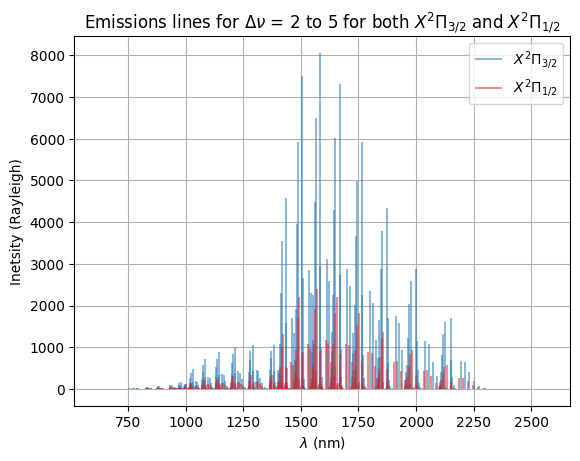

In [7]:
intensities1, lamdas1 = compute(state=1.5)
I1 = np.concatenate(list(intensities1.values()))
lamda1 = np.concatenate(list(lamdas1.values()))

intensities2, lamdas2 = compute(state=0.5)
I2 = np.concatenate(list(intensities2.values()))
lamda2 = np.concatenate(list(lamdas2.values()))

# Plot the intensity data with lines connecting to the x-axis
plt.scatter(lamda1, I1, marker='', linestyle='-')
plt.vlines(lamda1, 0, I1, colors='C0', linestyles='-', alpha=0.5, label=r"$X^{2} \Pi_{3/2}$")  # Lines connecting to x-axis

plt.scatter(lamda2, I2, marker='', linestyle='-')
plt.vlines(lamda2, 0, I2, colors='C3', linestyles='-', alpha=0.5, label=r"$X^{2} \Pi_{1/2}$")  # Lines connecting to x-axis

plt.xlabel(r"$\lambda$ (nm)")
plt.ylabel("Inetsity (Rayleigh)")
plt.legend()

plt.grid()
plt.title(r"Emissions lines for $\Delta\nu$ = 2 to 5 for both $X^{2} \Pi_{3/2}$ and $X^{2} \Pi_{1/2}$")
#plt.savefig("spectrum.pdf")
plt.show()

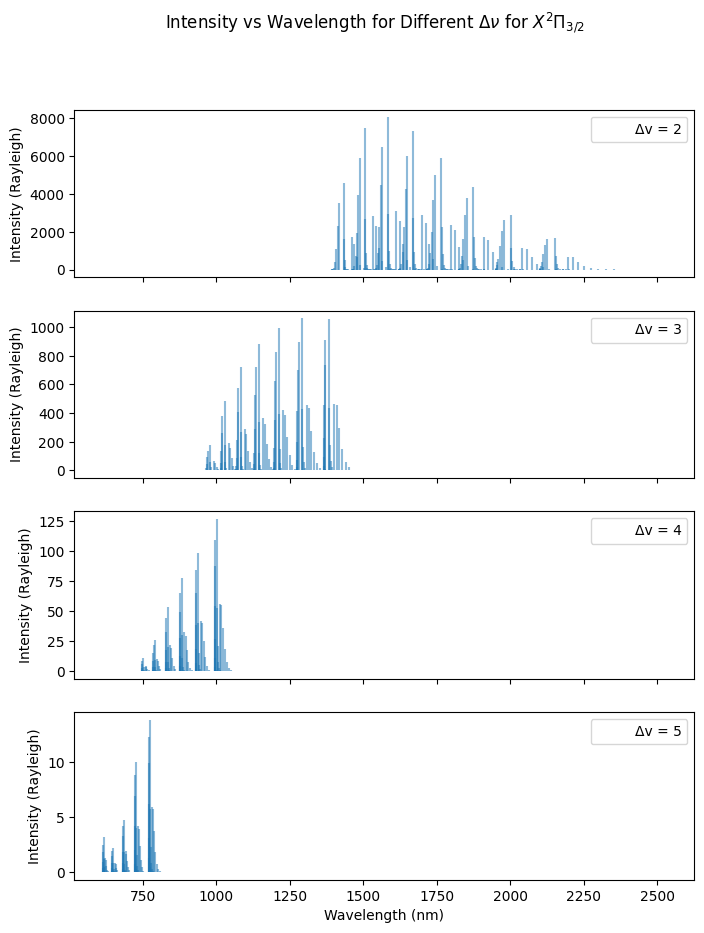

In [8]:
# Create subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

#print(np.max(intensities1[5]))

# Plot the intensities for each Δv on separate subplots
for delta_v in [2,3,4,5]:
    #print(delta_v)
    wavelengths = lamdas1[delta_v]
    intensities = intensities1[delta_v]
    
    axs[delta_v-2].scatter(wavelengths, intensities, label=f"Δv = {delta_v}", marker='', linestyle='-')
    axs[delta_v-2].vlines(wavelengths, 0, intensities, colors='C0', linestyles='-', alpha=0.5)  # Lines connecting to x-axis
    axs[delta_v-2].set_ylabel("Intensity (Rayleigh)")
    axs[delta_v-2].legend()

axs[-1].set_xlabel("Wavelength (nm)")
#plt.legend()
#plt.grid()
plt.suptitle(r"Intensity vs Wavelength for Different $\Delta\nu$ for $X^{2} \Pi_{3/2}$")
#plt.savefig("3Pi_2.pdf")
plt.show()

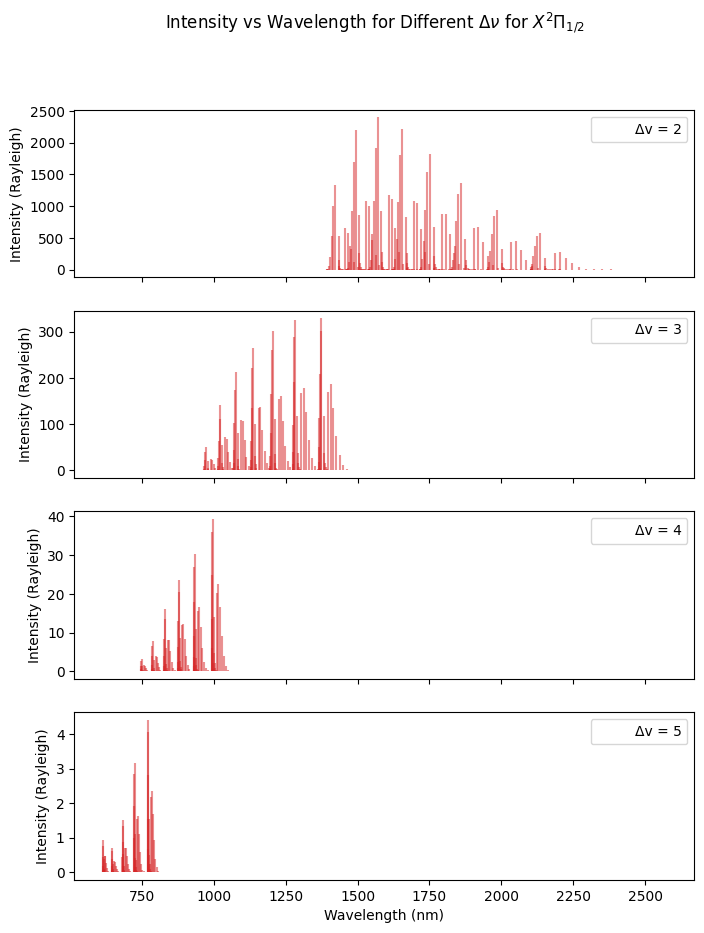

In [9]:
# Create subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

#print(np.max(intensities1[5]))

# Plot the intensities for each Δv on separate subplots
for delta_v in [2,3,4,5]:
    #print(delta_v)
    wavelengths = lamdas2[delta_v]
    intensities = intensities2[delta_v]
    
    axs[delta_v-2].scatter(wavelengths, intensities, label=f"Δv = {delta_v}", marker='', linestyle='-')
    axs[delta_v-2].vlines(wavelengths, 0, intensities, colors='C3', linestyles='-', alpha=0.5)  # Lines connecting to x-axis
    axs[delta_v-2].set_ylabel("Intensity (Rayleigh)")
    axs[delta_v-2].legend()

axs[-1].set_xlabel("Wavelength (nm)")
#plt.legend()
#plt.grid()
plt.suptitle(r"Intensity vs Wavelength for Different $\Delta\nu$ for $X^{2} \Pi_{1/2}$")
#plt.savefig("Pi_2.pdf")
plt.show()